In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("industry_dataset_csv.csv")

In [22]:
df.head()
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      15000 non-null  int64  
 1   company_name            15000 non-null  object 
 2   industry                15000 non-null  object 
 3   country                 15000 non-null  object 
 4   employee_count          15000 non-null  int64  
 5   annual_revenue_million  15000 non-null  float64
 6   profit_margin_percent   15000 non-null  float64
 7   founded_year            15000 non-null  int64  
 8   customer_count          15000 non-null  int64  
 9   market_rating           15000 non-null  float64
 10  created_date            15000 non-null  object 
 11  region                  15000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


,id,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,2606.862067,549.732707,25.012019,2004.374000,50449.251867,2.513780
std,4330.271354,1430.562513,288.244128,11.526187,8.606687,28744.638830,1.447998
min,1.000000,100.000000,50.160000,5.000000,1990.000000,500.000000,0.000000
25%,3750.750000,1379.000000,299.915000,15.050000,1997.000000,25676.250000,1.200000
50%,7500.500000,2587.000000,543.920000,24.910000,2004.000000,50726.500000,2.500000
75%,11250.250000,3839.000000,797.570000,35.100000,2012.000000,75271.250000,3.800000
max,15000.000000,5099.000000,1049.960000,45.000000,2019.000000,100495.000000,5.000000


In [24]:
df.isnull().sum()

id                        0
company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
dtype: int64

In [26]:
df.duplicated().sum()

0

In [30]:
df['created_date'] = pd.to_datetime(
    df['created_date'],
    dayfirst=True
)

In [36]:
#Univariate Analysis
df['created_date'].head()

0   2025-10-13
1   2025-12-01
2   2025-05-04
3   2026-02-01
4   2025-06-29
Name: created_date, dtype: datetime64[ns]

In [38]:
num_cols = [
    'employee_count',
    'annual_revenue_million',
    'profit_margin_percent',
    'founded_year',
    'customer_count',
    'market_rating'
]

for col in num_cols:
    print("\n", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Std:", df[col].std())
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print("Skewness:", df[col].skew())
    print("Kurtosis:", df[col].kurt())


 employee_count
Mean: 2606.8620666666666
Median: 2587.0
Std: 1430.5625126902269
Min: 100
Max: 5099
Skewness: 0.0023535190865822094
Kurtosis: -1.187695055652189

 annual_revenue_million
Mean: 549.7327066666667
Median: 543.9200000000001
Std: 288.2441284051724
Min: 50.16
Max: 1049.96
Skewness: 0.027341229189337332
Kurtosis: -1.1870590784106312

 profit_margin_percent
Mean: 25.01201933333333
Median: 24.91
Std: 11.526186847110754
Min: 5.0
Max: 45.0
Skewness: 0.002560347440879774
Kurtosis: -1.2025661193949446

 founded_year
Mean: 2004.374
Median: 2004.0
Std: 8.606687070963478
Min: 1990
Max: 2019
Skewness: 0.02060485029807918
Kurtosis: -1.1896089581740226

 customer_count
Mean: 50449.251866666666
Median: 50726.5
Std: 28744.638830209726
Min: 500
Max: 100495
Skewness: -0.00486592772365837
Kurtosis: -1.1947135992732298

 market_rating
Mean: 2.5137799999999997
Median: 2.5
Std: 1.4479976604775189
Min: 0.0
Max: 5.0
Skewness: -0.020033468814409698
Kurtosis: -1.2057607795157774


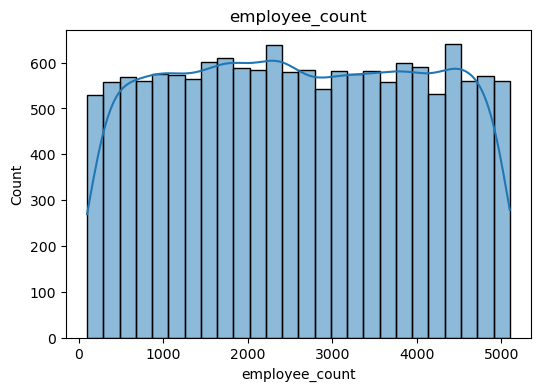

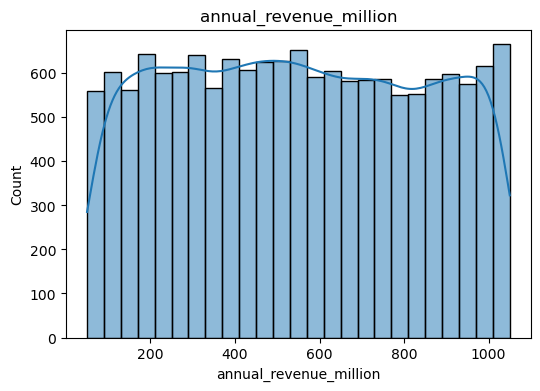

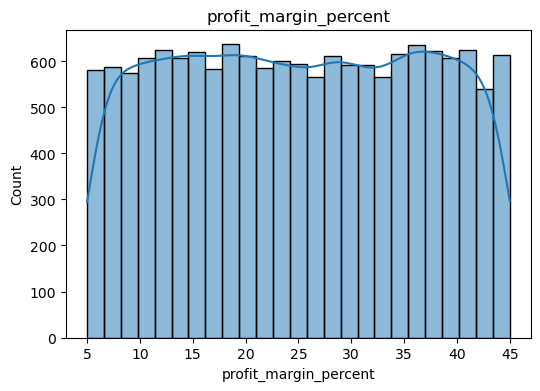

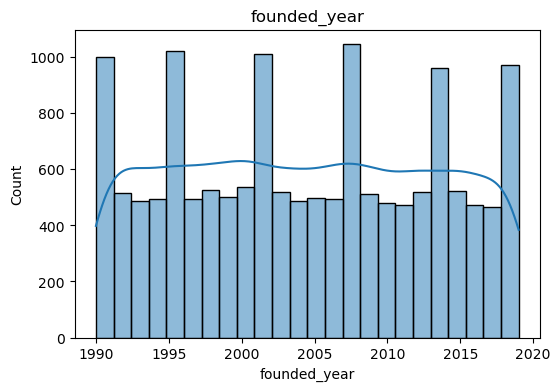

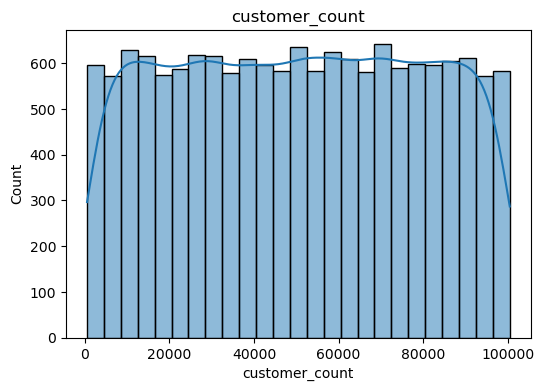

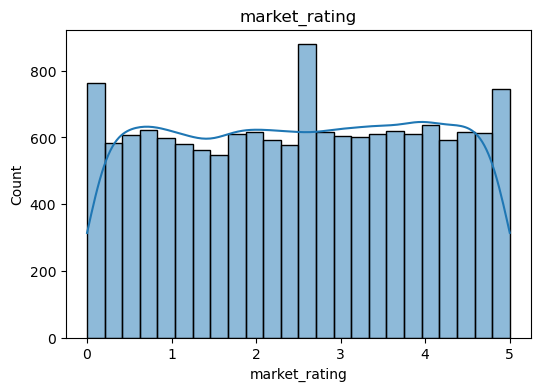

In [42]:
#Histogram
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

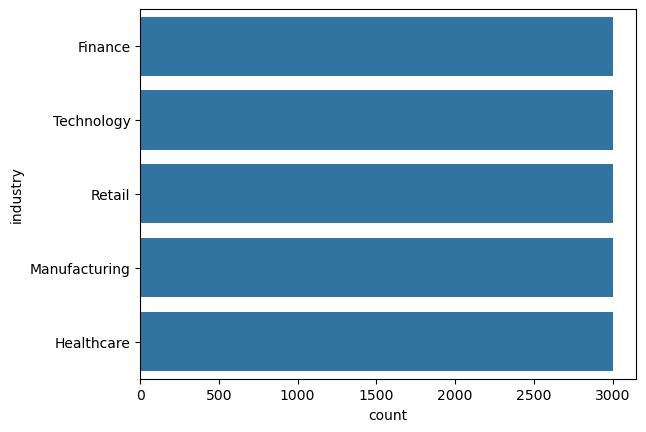

In [44]:
df['industry'].value_counts()

sns.countplot(y=df['industry'])
plt.show()

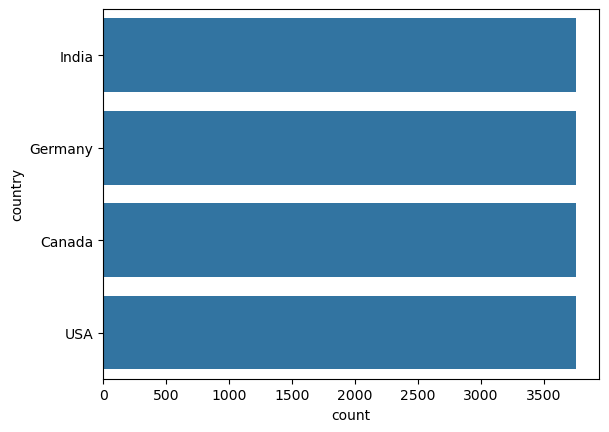

In [46]:
df['country'].value_counts()
sns.countplot(y=df['country'])
plt.show()

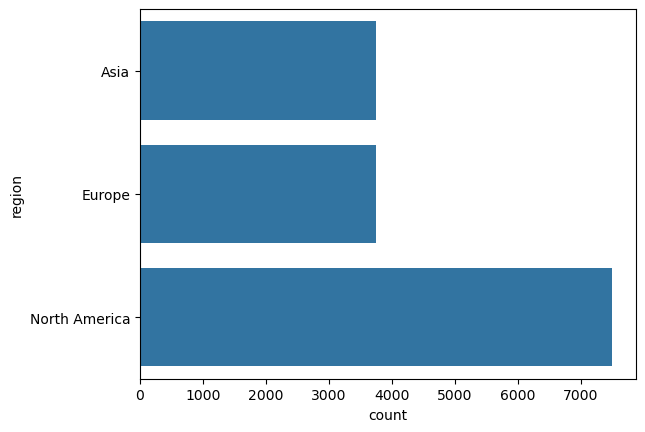

In [48]:
df['region'].value_counts()
sns.countplot(y=df['region'])
plt.show()

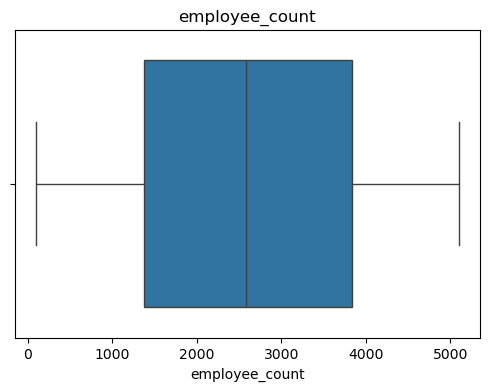

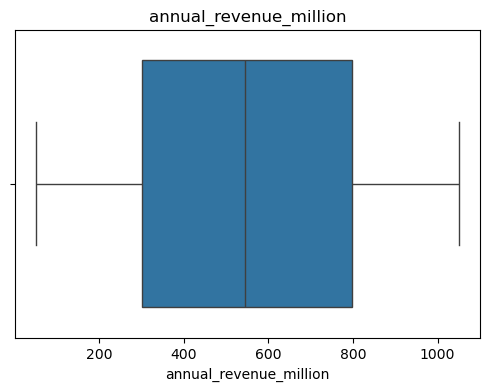

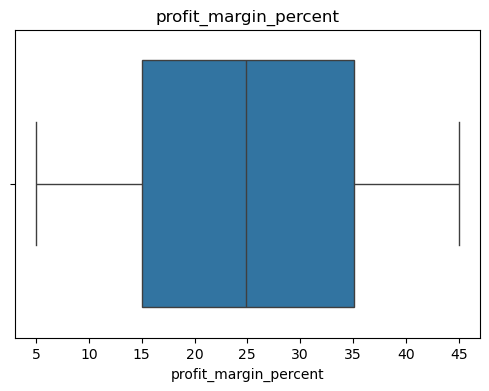

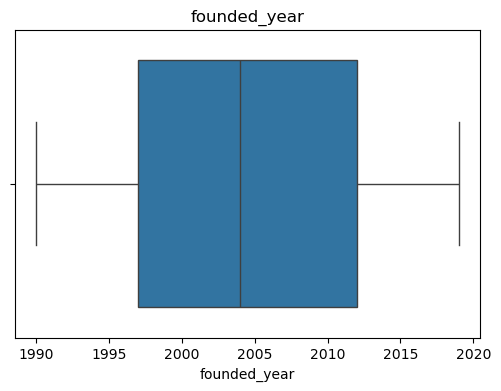

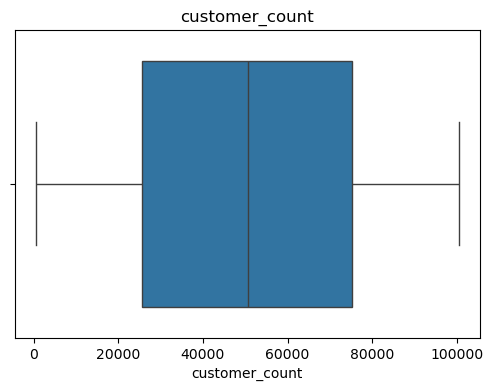

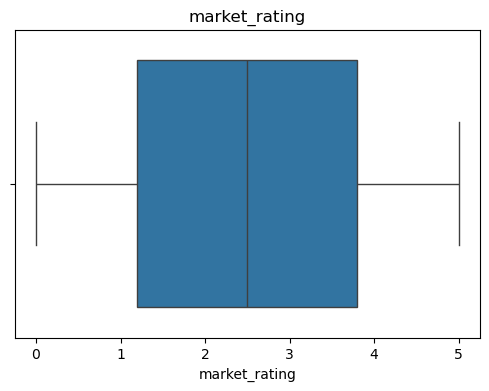

In [50]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [52]:
Q1 = df['annual_revenue_million'].quantile(0.25)
Q3 = df['annual_revenue_million'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['annual_revenue_million'] < lower) |
              (df['annual_revenue_million'] > upper)]

print("Outliers:", len(outliers))

Outliers: 0


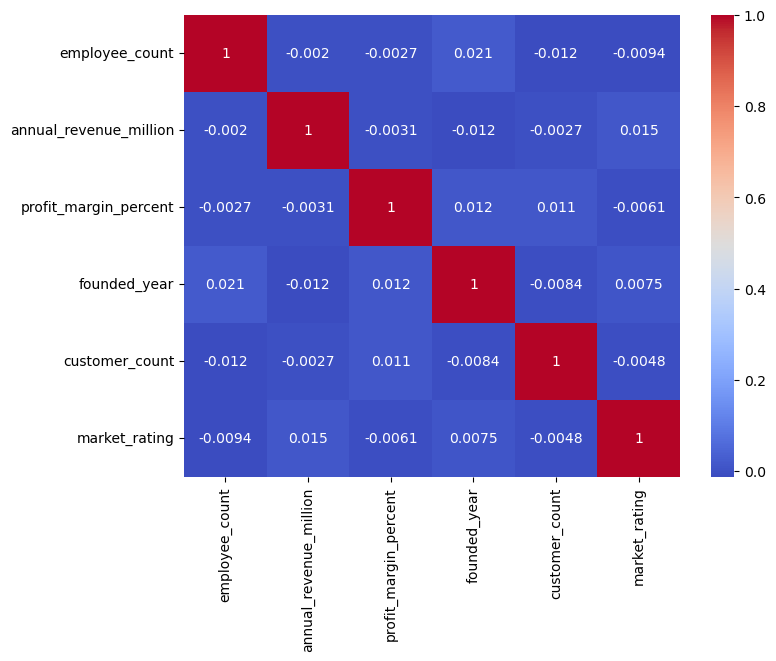

In [54]:
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

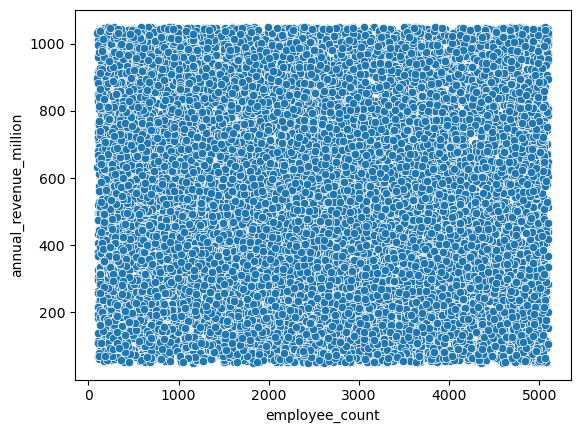

In [56]:
sns.scatterplot(
    data=df,
    x='employee_count',
    y='annual_revenue_million'
)
plt.show()

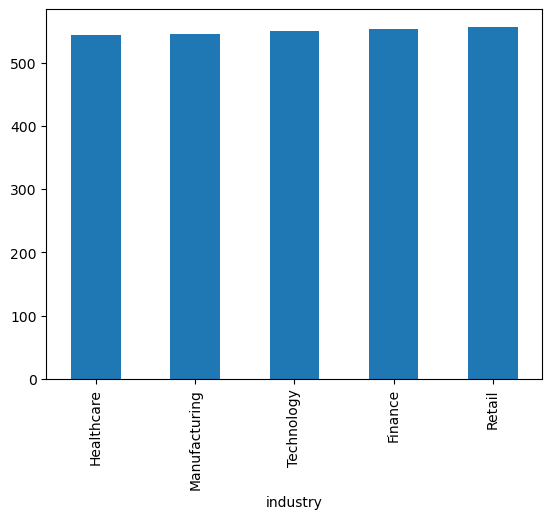

In [58]:
industry_rev = df.groupby('industry')['annual_revenue_million'].mean()

industry_rev.sort_values().plot(kind='bar')
plt.show()

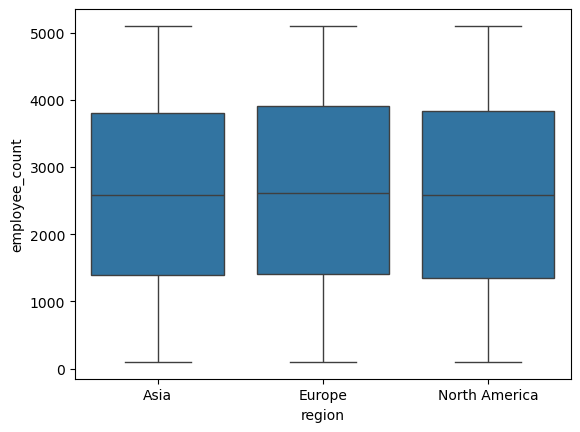

In [60]:
sns.boxplot(
    data=df,
    x='region',
    y='employee_count'
)
plt.show()

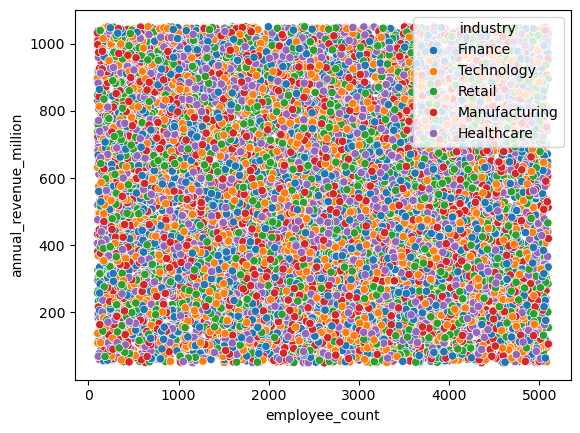

In [62]:
sns.scatterplot(
    data=df,
    x='employee_count',
    y='annual_revenue_million',
    hue='industry'
)
plt.show()

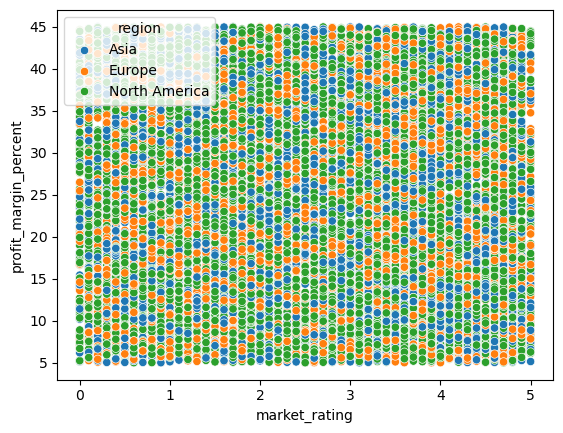

In [64]:
sns.scatterplot(
    data=df,
    x='market_rating',
    y='profit_margin_percent',
    hue='region'
)
plt.show()

In [66]:
for col in num_cols:
    print(col)
    print("Skewness:", round(df[col].skew(),2))
    print("Kurtosis:", round(df[col].kurt(),2))

employee_count
Skewness: 0.0
Kurtosis: -1.19
annual_revenue_million
Skewness: 0.03
Kurtosis: -1.19
profit_margin_percent
Skewness: 0.0
Kurtosis: -1.2
founded_year
Skewness: 0.02
Kurtosis: -1.19
customer_count
Skewness: -0.0
Kurtosis: -1.19
market_rating
Skewness: -0.02
Kurtosis: -1.21


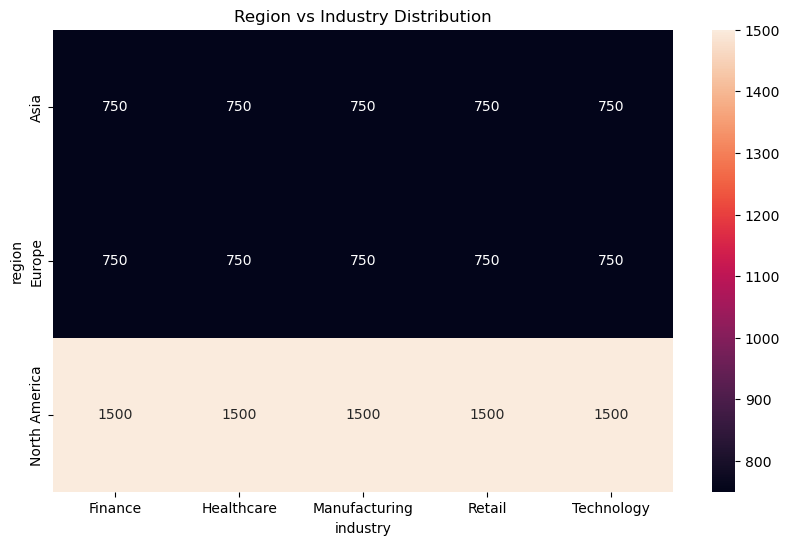

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

region_industry = pd.crosstab(df['region'], df['industry'])

plt.figure(figsize=(10,6))
sns.heatmap(region_industry, annot=True, fmt='d')
plt.title('Region vs Industry Distribution')
plt.show()